In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import mnist


In [2]:
#load the MNIST Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#Helper function for training and evaluation
def evaluate_mnist(preprocess_fn=None):
    X_train, X_test = x_train, x_test
    if preprocess_fn:
        X_train, X_test = preprocess_fn(X_train, X_test)
    clf = LogisticRegression(max_iter=200)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    return accuracy_score(y_test, pred)


In [4]:
# No Processing
acc_no = evaluate_mnist()

# MinMaxScaler
def mm_scale(a, b):
    scaler = MinMaxScaler()
    return scaler.fit_transform(a), scaler.transform(b)
acc_mm = evaluate_mnist(mm_scale)

# StandardScaler
def std_scale(a, b):
    scaler = StandardScaler()
    return scaler.fit_transform(a), scaler.transform(b)
acc_std = evaluate_mnist(std_scale)

# QuantileTransformer
def quant_scale(a, b):
    scaler = QuantileTransformer(n_quantiles=100)
    return scaler.fit_transform(a), scaler.transform(b)
acc_qt = evaluate_mnist(quant_scale)

# PCA
def pca_reduce(a, b):
    pca = PCA(n_components=100)
    return pca.fit_transform(a), pca.transform(b)
acc_pca = evaluate_mnist(pca_reduce)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

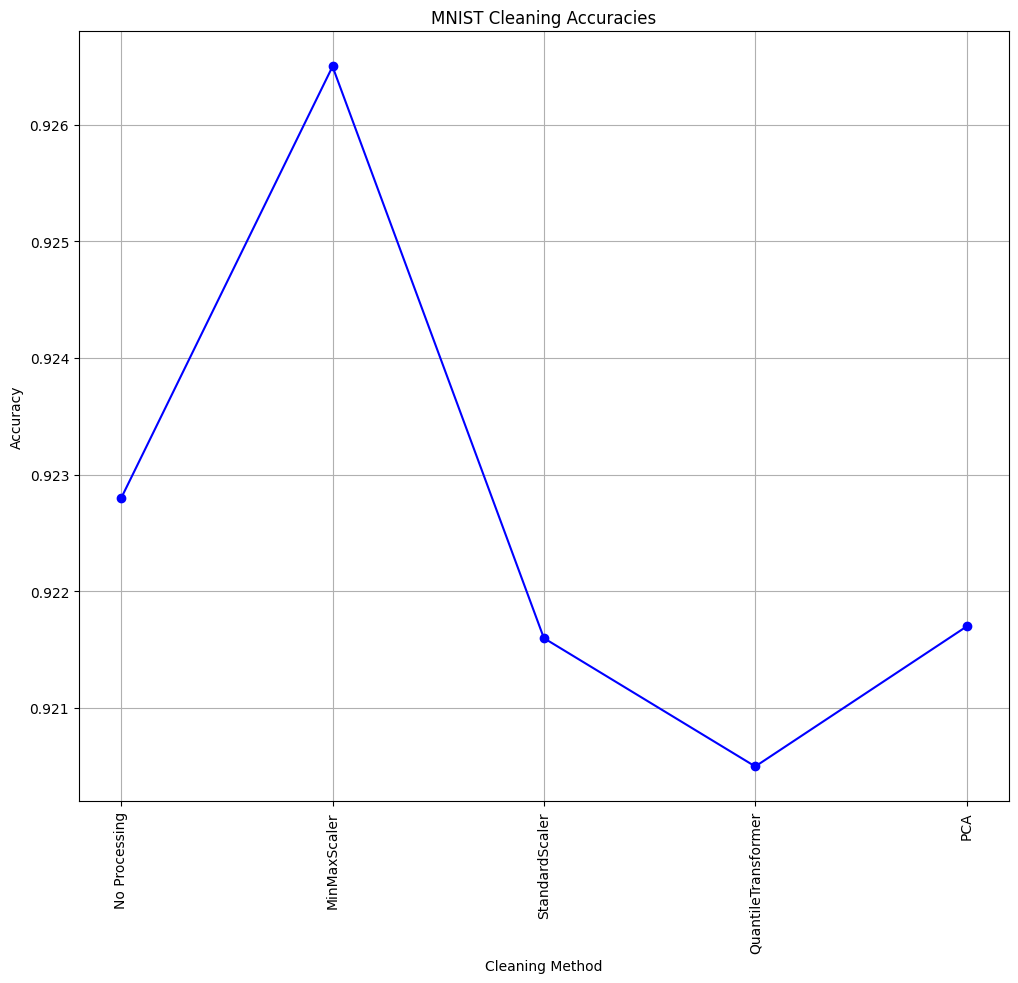

In [11]:
# Accuracy results for MNIST
mnist_accuracies = {
    "No Processing": acc_no,
    "MinMaxScaler": acc_mm,
    "StandardScaler": acc_std,
    "QuantileTransformer": acc_qt,
    "PCA": acc_pca
}

# Plotting
plt.figure(figsize=(12, 10))
plt.plot(list(mnist_accuracies.keys()), list(mnist_accuracies.values()), marker='o', linestyle='-', color='b')
plt.title("MNIST Cleaning Accuracies")
plt.xlabel("Cleaning Method")
plt.ylabel("Accuracy")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()



# **Conclusion for MNIST**

For MNIST, MinMaxScaler provides the best performance. Raw data without preprocessing also performs decently due to the simplicity of the dataset. PCA, though useful for dimensionality reduction, shows lower performance as it eliminates some important features for classification.